In [ ]:
# SEPARATE CHIP LOGIC BY BASIN TYPE

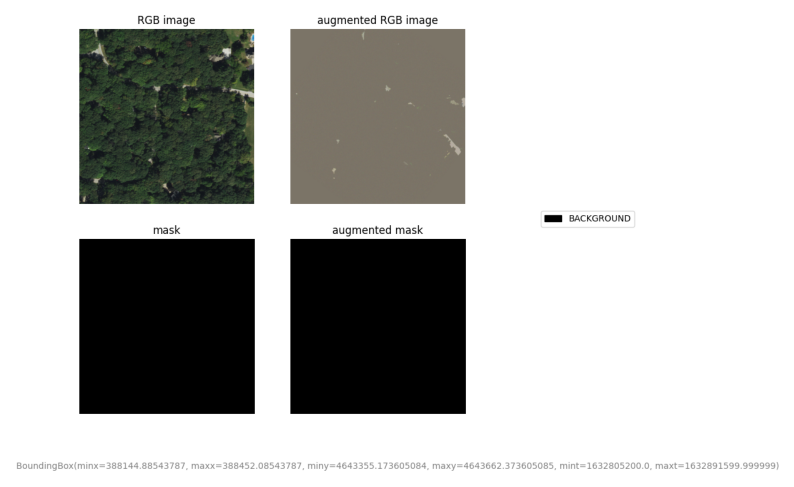

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the PNG file
image_path = "/net/projects/cmap/workspaces/annapoon/testing_rd_train_28_trial_0/train-images/epoch-1/train_sample-1.15.png"
#image_path = "/net/projects/cmap/workspaces/annapoon/testing_rd_train_17_trial_0/test-images/epoch-1/UNKNOWN/test_sample-1.0.5.png"

# Load and display the image
img = mpimg.imread(image_path)
plt.figure(figsize=(10, 10))  # Set the figure size (width, height)

plt.imshow(img)
plt.axis('off')  # Hide axes for better visualization
plt.show()


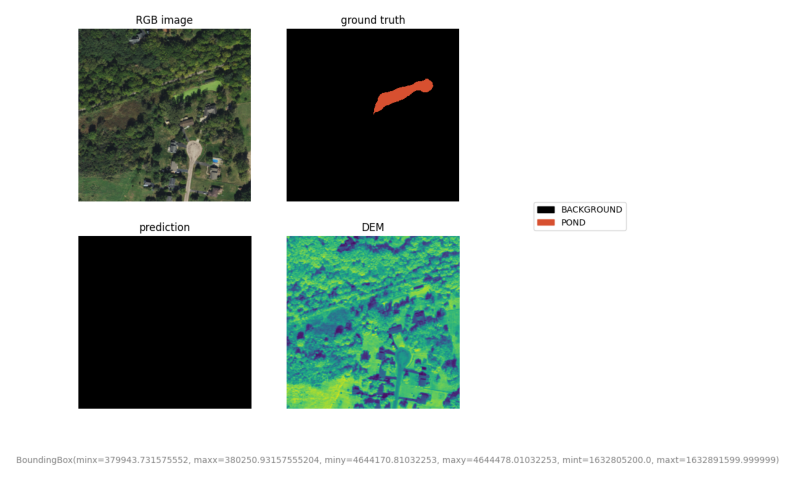

In [50]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the PNG file
#image_path = "/net/projects/cmap/workspaces/annapoon/testing_rd_train_23_trial_0/train-images/epoch-1/train_sample-1.5.png"
#image_path = "/net/projects/cmap/workspaces/annapoon/testing_rd_train_28_trial_0/test-images/epoch-2/UNKNOWN/test_sample-2.0.2.png"
image_path = "/net/projects/cmap/workspaces/annapoon/regular_training_1_22_trial_0/test-images/epoch-0/POND/test_sample-0.0.4.png"

# Load and display the image
img = mpimg.imread(image_path)
plt.figure(figsize=(10, 10))  # Set the figure size (width, height)

plt.imshow(img)
plt.axis('off')  # Hide axes for better visualization
plt.show()


In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
# RIVER DATASET
from pathlib import Path
import sys
from rd import RiverDataset
import torch
from torchgeo.datasets import BoundingBox
import sys
import os

# Example configuration for the dataset
rd_configs = (
    {5: "STREAM-RIVER", 0:"BACKGROUND"},  # Label mapping
    256,  # Patch size
    "EPSG:4326",  # Destination CRS
    0.1,  # Resolution in CRS units
)

rd_path = "/net/projects/cmap/data/kane-county-data/Kane_Co_Open_Water_Layer.zip"

# Create RiverDataset instance with both KC and river data
river_dataset = RiverDataset(rd_path, rd_configs, kc=True)

# Access the combined dataset
print(river_dataset.gdf.head())

Initial Kane County GeoDataFrame loaded:
           BasinType                                           geometry
0               POND  MULTIPOLYGON (((945992.273 1935539.526, 945981...
1  DRY BOTTOM - TURF  MULTIPOLYGON (((957439.997 1930555.492, 957416...
2               POND  MULTIPOLYGON (((947040.816 1927034.962, 947028...
3               POND  MULTIPOLYGON (((948408.045 1926341.826, 948397...
4               POND  MULTIPOLYGON (((947424.509 1925889.426, 947443...
Kane countys filtered gdf
           BasinType                                           geometry
0               POND  MULTIPOLYGON (((-88.47404 41.98057, -88.47408 ...
1  DRY BOTTOM - TURF  MULTIPOLYGON (((-88.43192 41.96693, -88.43200 ...
2               POND  MULTIPOLYGON (((-88.47013 41.95723, -88.47018 ...
3               POND  MULTIPOLYGON (((-88.46510 41.95534, -88.46514 ...
4               POND  MULTIPOLYGON (((-88.46872 41.95409, -88.46865 ...
Initialized KC dataset with (4, {'BACKGROUND': 0, 'POND': 1, 'WETLAND

Processing x-axis:   1%|          | 132/17236 [00:10<21:51, 13.05it/s]


Total chips inserted: 27
Initialized RiverDataset with configs: ({5: 'STREAM-RIVER', 0: 'BACKGROUND'}, 256, 'EPSG:4326', 0.1)
   OBJECTID_1  OBJECTID         FCODE AddUser AddDate EditUser EditDate  \
6       448.0     502.0  STREAM-RIVER    None    None     None     None   
7         NaN       NaN           NaN     NaN     NaN      NaN      NaN   
8         NaN       NaN           NaN     NaN     NaN      NaN      NaN   
9         NaN       NaN           NaN     NaN     NaN      NaN      NaN   

      Shape_STAr    Shape_STLe  \
6  200773.926749  15320.271333   
7            NaN           NaN   
8            NaN           NaN   
9            NaN           NaN   

                                            geometry          BasinType  
6  POLYGON ((-88.60211 41.73055, -88.60211 41.730...       STREAM-RIVER  
7  MULTIPOLYGON (((-88.47404 41.98057, -88.47408 ...               POND  
8  MULTIPOLYGON (((-88.43192 41.96693, -88.43200 ...  DRY BOTTOM - TURF  
9  MULTIPOLYGON (((-88.47013 41

Setting plot limits: minx=-88.60210943274505, miny=41.71979852550066, maxx=-88.43050943274498, maxy=41.98258576971991
Plot X Limits: (-88.60210943274505, -88.43050943274498)
Plot Y Limits: (41.71979852550066, 41.98258576971991)


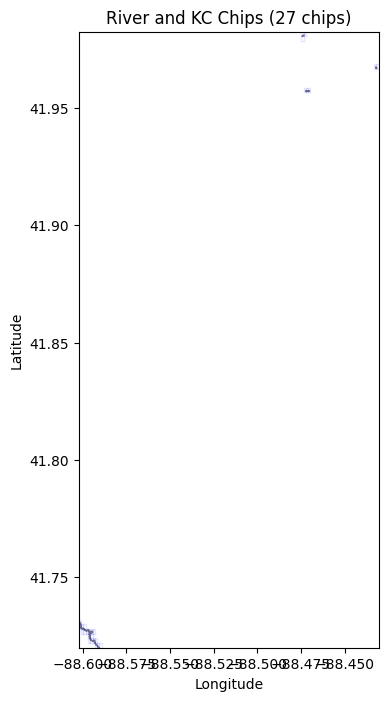

river chip count: 27


In [3]:
import matplotlib.pyplot as plt
from shapely.geometry import box

# Create a new figure
fig, ax = plt.subplots(figsize=(8, 8))  # Adjust the second value to make it taller

# Plot the geometries in river_dataset.gdf
# Assuming 'geometry' column contains geometries of the river polygons
river_dataset.gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Initialize the river counter
river_counter = 0

# Initialize limits for plotting based on chips
minx_plot, miny_plot, maxx_plot, maxy_plot = float('inf'), float('inf'), -float('inf'), -float('inf')

# Loop through the R-tree index and extract bounding box coordinates
for item in river_dataset.index.intersection(river_dataset.index.bounds, objects=True):
    # Check the structure of item.bbox to understand the extra values
    #print(f"Item BBox: {item.bbox}")
    
    # Assuming bbox contains extra data, extracting the expected (minx, maxx, miny, maxy) values
    # Accessing the coordinates according to your custom index structure
    minx, maxx, miny, maxy = item.bbox[0], item.bbox[1], item.bbox[3], item.bbox[4]
    bbox = [minx, miny, maxx, maxy]
    
    # Ensure bbox has valid coordinates (minx, miny, maxx, maxy)
    if len(bbox) == 4:
        # Update plot limits dynamically based on chip bounding boxes
        minx_plot = min(minx_plot, minx)
        miny_plot = min(miny_plot, miny)
        maxx_plot = max(maxx_plot, maxx)
        maxy_plot = max(maxy_plot, maxy)
        
        # Create a rectangle (chip) for the bounding box using Shapely
        chip = box(minx, miny, maxx, maxy)  # Create a chip using the custom bounding box
        
        # Extract the exterior coordinates of the chip (polygon)
        x, y = chip.exterior.xy
        
        # Plot the bounding box
        ax.plot(x, y, 'b-', lw=1, alpha=0.1)  # Plot using the exterior coordinates
        
        # Increment the counter
        river_counter += 1
    else:
        print(f"Skipping item with invalid bbox: {bbox}")

# Set plot limits based on the min/max of the bounding boxes
print(f"Setting plot limits: minx={minx_plot}, miny={miny_plot}, maxx={maxx_plot}, maxy={maxy_plot}")
ax.set_xlim(minx_plot, maxx_plot)
ax.set_ylim(miny_plot, maxy_plot)

# Double-check the limits to make sure they're correct:
print(f"Plot X Limits: {ax.get_xlim()}")
print(f"Plot Y Limits: {ax.get_ylim()}")

# Add titles and labels
ax.set_title(f"River and KC Chips ({river_counter} chips)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

# Print the total number of chips
print("river chip count:", river_counter)
    
    

# KC DATA

In [22]:
import torch
from torchgeo.datasets import BoundingBox
from kc import KaneCounty
import sys
import os

# Load the configuration settings
DATA_ROOT = "/net/projects/cmap/data"
KC_SHAPE_ROOT = os.path.join(DATA_ROOT, "kane-county-data")
KC_SHAPE_FILENAME = "KC_StormwaterDataJan2024.gdb.zip"  # Filename from config
KC_LAYER = 4  # Layer number from config
KC_LABELS = {
    "BACKGROUND": 0,
    "POND": 1,
    "WETLAND": 2,
    "DRY BOTTOM - TURF": 3,
    "DRY BOTTOM - MESIC PRAIRIE": 4,
}

# Assume the full path to the GeoPackage
path = os.path.join(KC_SHAPE_ROOT, KC_SHAPE_FILENAME)

# Configuration for the dataset
labels = KC_LABELS
patch_size = 256  # Size of the patches to be extracted
dest_crs = "EPSG:4326"  # Desired Coordinate Reference System (WGS84)
resolution = 0.0001  # Spatial resolution of the dataset

# Update configs to include the layer name
configs = (KC_LAYER, labels, patch_size, dest_crs, resolution)

# Create an instance of the KaneCounty dataset
kc_dataset = KaneCounty(path, configs)

# Example bounding box query (minx, maxx, miny, maxy, mint, maxt)
# Adjusted to fit within the dataset bounds
bbox = BoundingBox(
    minx=-89.6,       # Adjusted within the dataset minx
    maxx=-87.2,       # Adjusted within the dataset maxx
    miny=40.72,       # Adjusted within the dataset miny
    maxy=43.18,       # Adjusted within the dataset maxy
    mint=0,           # Optional: you can leave this as is
    maxt=sys.maxsize  # Optional: you can leave this as is
)

# Fetch data for this bounding box
try:
    sample = kc_dataset[bbox]  # Fetch sample for the bounding box
    # Print the sample (mask, CRS, bounding box)
    print("Mask shape:", sample['mask'].shape)
    print("CRS:", sample['crs'])
    print("Bounding Box:", sample['bbox'])
except IndexError as e:
    print(f"Error: {e}")

Mask shape: torch.Size([24600, 24000])
CRS: EPSG:4326
Bounding Box: BoundingBox(minx=-89.6, maxx=-87.2, miny=40.72, maxy=43.18, mint=0, maxt=9223372036854775807)


Setting plot limits: minx=-89.60202003549256, miny=40.71980207606885, maxx=-87.23831110170896, maxy=43.15395637299775
Plot X Limits: (-89.60202003549256, -87.23831110170896)
Plot Y Limits: (40.71980207606885, 43.15395637299775)


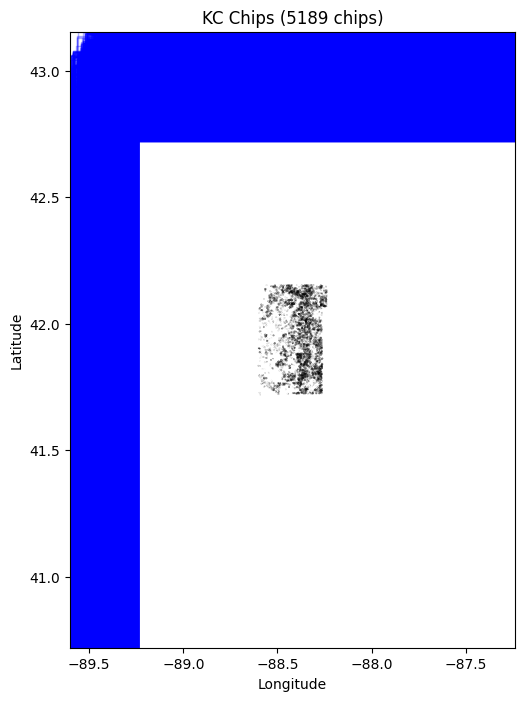

kc chip count: 5189


In [ ]:
import matplotlib.pyplot as plt
from shapely.geometry import box

# Create a new figure
fig, ax = plt.subplots(figsize=(8, 8))  # Adjust the second value to make it taller

# Plot the geometries in river_dataset.gdf
# Assuming 'geometry' column contains geometries of the river polygons
kc_dataset.gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Initialize the river counter
kc_counter = 0

# Initialize limits for plotting based on chips
minx_plot, miny_plot, maxx_plot, maxy_plot = float('inf'), float('inf'), -float('inf'), -float('inf')

# Loop through the R-tree index and extract bounding box coordinates
for item in kc_dataset.index.intersection(kc_dataset.index.bounds, objects=True):
    # Check the structure of item.bbox to understand the extra values
    #print(f"Item BBox: {item.bbox}")
    
    # Assuming bbox contains extra data, extracting the expected (minx, maxx, miny, maxy) values
    # Accessing the coordinates according to your custom index structure
    minx, maxx, miny, maxy = item.bbox[0], item.bbox[3], item.bbox[1], item.bbox[4]
    bbox = [minx, miny, maxx, maxy]
    
    # Ensure bbox has valid coordinates (minx, miny, maxx, maxy)
    if len(bbox) == 4:
        # Update plot limits dynamically based on chip bounding boxes
        minx_plot = min(minx_plot, minx)
        miny_plot = min(miny_plot, miny)
        maxx_plot = max(maxx_plot, maxx)
        maxy_plot = max(maxy_plot, maxy)
        
        # Create a rectangle (chip) for the bounding box using Shapely
        chip = box(minx, miny, maxx, maxy)  # Create a chip using the custom bounding box
        
        # Extract the exterior coordinates of the chip (polygon)
        x, y = chip.exterior.xy
        
        # Plot the bounding box
        ax.plot(x, y, 'b-', lw=1, alpha=0.3)  # Plot using the exterior coordinates
        
        # Increment the counter
        kc_counter += 1
    else:
        print(f"Skipping item with invalid bbox: {bbox}")

# Set plot limits based on the min/max of the bounding boxes
print(f"Setting plot limits: minx={minx_plot}, miny={miny_plot}, maxx={maxx_plot}, maxy={maxy_plot}")
ax.set_xlim(minx_plot, maxx_plot)
ax.set_ylim(miny_plot, maxy_plot)

# Double-check the limits to make sure they're correct:
print(f"Plot X Limits: {ax.get_xlim()}")
print(f"Plot Y Limits: {ax.get_ylim()}")

# Add titles and labels
ax.set_title(f"KC Chips ({kc_counter} chips)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

# Print the total number of chips
print("kc chip count:", kc_counter)
    
    

In [39]:
kc_dataset.gdf.geometry

0       MULTIPOLYGON (((-88.47404 41.98057, -88.47408 ...
1       MULTIPOLYGON (((-88.43192 41.96693, -88.43200 ...
2       MULTIPOLYGON (((-88.47013 41.95723, -88.47018 ...
3       MULTIPOLYGON (((-88.46510 41.95534, -88.46514 ...
4       MULTIPOLYGON (((-88.46872 41.95409, -88.46865 ...
                              ...                        
5362    MULTIPOLYGON (((-88.29351 41.88299, -88.29350 ...
5363    MULTIPOLYGON (((-88.33877 41.85403, -88.33873 ...
5364    MULTIPOLYGON (((-88.33783 41.85410, -88.33769 ...
5365    MULTIPOLYGON (((-88.32936 41.84522, -88.32936 ...
5366    MULTIPOLYGON (((-88.34524 41.93832, -88.34522 ...
Name: geometry, Length: 5189, dtype: geometry

In [41]:
river_dataset.gdf.geometry

4       POLYGON ((-88.26169 41.73687, -88.26169 41.736...
6       POLYGON ((-88.28127 41.72802, -88.28127 41.728...
23      POLYGON ((-88.33520 41.93227, -88.33520 41.932...
64      POLYGON ((-88.30586 41.76648, -88.30583 41.766...
65      POLYGON ((-88.30693 41.76640, -88.30684 41.766...
                              ...                        
8935    MULTIPOLYGON (((-88.29351 41.88299, -88.29350 ...
8936    MULTIPOLYGON (((-88.33877 41.85403, -88.33873 ...
8937    MULTIPOLYGON (((-88.33783 41.85410, -88.33769 ...
8938    MULTIPOLYGON (((-88.32936 41.84522, -88.32936 ...
8939    MULTIPOLYGON (((-88.34524 41.93832, -88.34522 ...
Name: geometry, Length: 5365, dtype: geometry